<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Target Encoding y Suavizado con Regularización Bayesiana 🧗
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 06
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>


---
## Los Desafíos del Target Encoding Básico ⚠️

Una codificación por la media (*Target Encoding simple*) presenta dos problemas fundamentales que pueden degradar severamente la capacidad de generalización de un modelo de Machine Learning:

1. **Categorías Desconocidas (*Unknown Categories*):**
   El Target Encoding genera un riesgo elevado de sobreajuste (*overfitting*), lo que significa que el codificador debe entrenarse en una partición de datos independiente (*encoding split*). Cuando unas la codificación a futuras particiones o datos en producción, Pandas o Scikit-Learn generarán valores faltantes (`NaN`) para cualquier categoría que no estuviese presente en el conjunto de entrenamiento. Esos valores faltantes tendrían que ser imputados de alguna forma.

2. **Categorías Raras o Infrecuentes (*Rare Categories*):**
   Cuando una categoría ocurre solo unas pocas veces en el conjunto de datos, cualquier estadística calculada sobre ese grupo difícilmente será representativa. 
   - *Ejemplo en el dataset de Automóviles:* La marca `mercury` aparece una sola vez. El precio promedio que calculamos es simplemente el precio de ese único vehículo, el cual podría no ser representativo de futuros autos Mercury que observemos en producción. Codificar categorías raras sin control aumenta la probabilidad de sobreajuste.

---
### La Solución: Regularización mediante Suavizado (*Smoothing*) 💡

Una solución elegante y estadísticamente rigurosa a estos problemas es agregar **suavizado (*smoothing*)**.

La idea central es combinar (*blend*) el promedio dentro de la categoría con el **promedio global** de todo el conjunto de datos:
- Las categorías raras reciben **menos peso** en su promedio intra-categoría y más peso en el promedio global.
- Las categorías desconocidas o faltantes simplemente reciben el **promedio global**.

### En Pseudocódigo:
$$\text{encoding} = \text{weight} \times \text{in\_category} + (1 - \text{weight}) \times \text{overall}$$

Donde `weight` es un valor entre $0$ y $1$ calculado a partir de la frecuencia de aparición de la categoría.

### El Estimador $m$ (*$m$-estimate*):
Una forma estándar y ampliamente utilizada para determinar el valor de `weight` es calcular una **estimación $m$**:

$$\text{weight} = \frac{n}{n + m}$$

Donde:
- $n$: Número total de veces que esa categoría aparece en los datos (frecuencia).
- $m$: Parámetro de **factor de suavizado (*smoothing factor*)**. Valores más grandes de $m$ otorgan mayor peso a la estimación global (*overall estimate*).

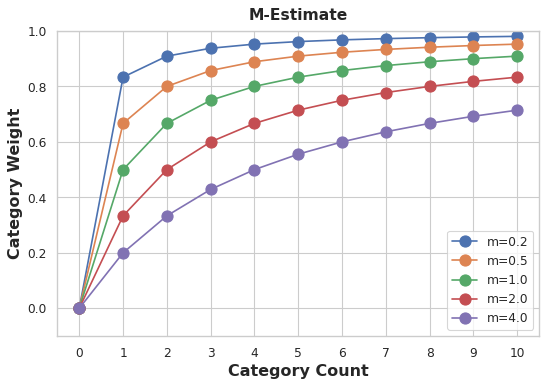

#### Ejemplo Numérico con el Dataset de Automóviles 🚗
En el dataset de automóviles hay 3 autos de la marca `chevrolet` ($n=3$, precio medio de Chevrolet = $6,000.00) y el precio medio global es de $13,285.03.

Si elegimos un factor de suavizado $m = 2.0$:
$$\text{weight} = \frac{3}{3 + 2.0} = \frac{3}{5} = 0.60$$

Por lo tanto, la categoría `chevrolet` se codificará con el 60% del precio promedio de Chevrolet más el 40% del precio promedio general:
$$\text{chevrolet} = 0.60 \times 6000.00 + 0.40 \times 13285.03 = 3600.00 + 5314.01 = 8914.01$$

> 🧠 **¿Cómo elegir el valor de $m$?**
> Al seleccionar un valor para $m$, considera qué tan ruidosas esperas que sean las categorías:
> - ¿El precio de un vehículo varía enormemente dentro de cada marca? ¿Necesitarías muchos datos para obtener estimaciones estables? Si es así, es mejor elegir un valor mayor para $m$.
> - Si el precio promedio de cada marca fuera relativamente homogéneo y estable, un valor menor de $m$ será suficiente.

---
### 1. Configuración del Entorno (*Setup the notebook*) 🛠️

Cargamos las librerías necesarias y configuramos el entorno interactivo de Jupyter:

In [1]:
try:
    from IPython.core.interactiveshell import InteractiveShell
    InteractiveShell.ast_node_interactivity = 'all'
except Exception:
    pass
try:
    from IPython.display import display
except Exception:
    pass

# Visualización y cálculo numérico
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Preprocesamiento y codificación de Scikit-Learn
from sklearn.preprocessing import TargetEncoder


# Estilo de gráficos
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente.")


✅ Librerías cargadas correctamente.


---
### 2. Comportamiento Matemático del Factor $m$ (*M-Estimate Visualization*) 📈

Grafiquemos cómo evoluciona el peso asignado a la categoría (`Category Weight`) a medida que aumenta el número de observaciones observadas (`Category Count`), comparando diferentes valores de $m$ ($0.2, 0.5, 1.0, 2.0, 4.0$):

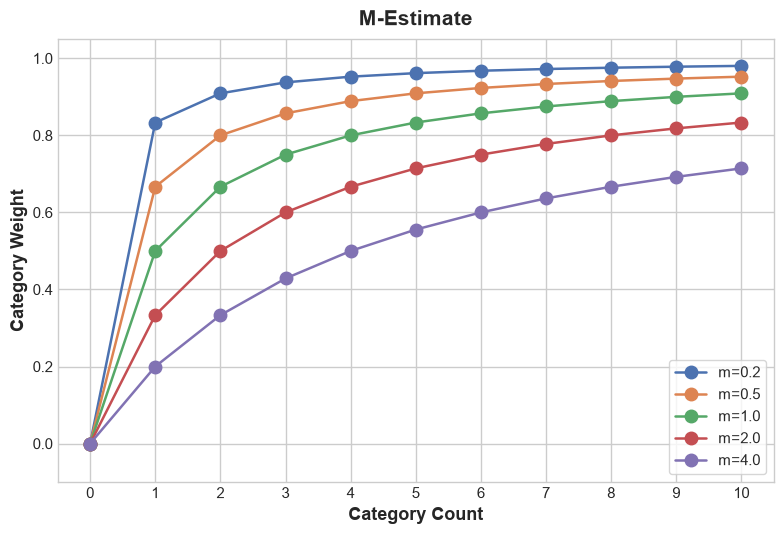

In [2]:
# Rango de observaciones observadas por categoría (0 a 10)
n_counts = np.arange(0, 11)
m_values = [0.2, 0.5, 1.0, 2.0, 4.0]

plt.figure(figsize=(8, 5.5))

for m in m_values:
    weights = n_counts / (n_counts + m)
    plt.plot(n_counts, weights, marker='o', markersize=9, linewidth=1.8, label=f'm={m}')

plt.title("M-Estimate", fontsize=15, weight='bold')
plt.xlabel("Category Count", fontsize=13, weight='bold')
plt.ylabel("Category Weight", fontsize=13, weight='bold')
plt.xticks(n_counts)
plt.ylim(-0.1, 1.05)
plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()


---
### 3. Casos de Uso Ideales para Target Encoding (*Use Cases*) 🎯

El Target Encoding es especialmente útil en los siguientes escenarios:

1. **Características de Alta Cardinalidad (*High-cardinality features*):**
   Una característica con cientos o miles de categorías (códigos postales, ocupaciones, ciudades, modelos de productos) resulta problemática de codificar: *One-Hot Encoding* generaría miles de columnas dispersas consumiendo memoria excesiva, mientras que *Ordinal Encoding* podría imponer un orden arbitrario perjudicial. Target Encoding resume la relación entre la categoría y la variable objetivo en una **única columna numérica continua**.

2. **Características Motivadas por el Dominio (*Domain-motivated features*):**
   Por experiencia previa en el negocio, podrías sospechar que una variable categórica debería ser altamente informativa aunque obtenga un puntaje bajo en métricas lineales directas. Target Encoding ayuda a revelar la verdadera capacidad explicativa de la variable.

> 📖 Para profundizar en los fundamentos matemáticos, consulta el artículo de Towards Data Science: ["Encoding Categorical Variables: A Deep Dive into Target Encoding"](https://towardsdatascience.com/encoding-categorical-variables-a-deep-dive-into-target-encoding-2862217c2753).

---
### 4. Ejemplo Práctico 1: Dataset de Automóviles de 1985 (`autos.csv`) 🚗

Carguemos el dataset de automóviles para observar el cálculo del promedio por marca y su versión suavizada con el estimador $m$:

In [3]:
import os
import urllib.request

# --- Carga de Datos con Resolución de Rutas y Fallback ---
file_path_autos = 'data/autos.csv'
if not os.path.exists(file_path_autos) and os.path.exists(f'06 - Feature Engineering/{file_path_autos}'):
    file_path_autos = f'06 - Feature Engineering/{file_path_autos}'

if not os.path.exists(file_path_autos):
    print('Descargando dataset autos.csv...')
    os.makedirs(os.path.dirname(file_path_autos), exist_ok=True)
    url = 'https://raw.githubusercontent.com/ricber/data-science-course/master/06-Feature%20Engineering/data/autos.csv'
    urllib.request.urlretrieve(url, file_path_autos)
# --------------------------------------------------------

# Cargamos el dataset de autos
autos = pd.read_csv(file_path_autos)

# Target Encoding simple (media por grupo)
autos["make_encoded"] = autos.groupby("make")["price"].transform("mean")
autos[["make", "price", "make_encoded"]].head(10)


,make,price,make_encoded
0,alfa-romero,13495,15498.333333
1,alfa-romero,16500,15498.333333
2,alfa-romero,16500,15498.333333
3,audi,13950,17859.166667
4,audi,17450,17859.166667
5,audi,15250,17859.166667
6,audi,17710,17859.166667
7,audi,18920,17859.166667
8,audi,23875,17859.166667
9,bmw,16430,26118.750000


---
##### 🛠️ Práctica 1: Calculando Target Encoding con Suavizado ($m$-Estimate) Manual

Calcula el promedio general de la columna `price` en `autos` (`overall_mean`) y aplica la fórmula de $m$-estimate con $m=2.0$ para codificar la columna `'make'`. Guarda el resultado en una nueva columna llamada `'make_smoothed'` y compara las marcas con pocas observaciones (como `'mercury'` o `'chevrolet'`).

In [ ]:
# Escribe tu código aquí

# overall_mean = ...
# autos['make_smoothed'] = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1. Calculamos la media global
overall_mean = autos['price'].mean()

# 2. Calculamos la frecuencia (n) y la media por marca (in_category)
n = autos.groupby('make')['price'].transform('count')
in_category = autos.groupby('make')['price'].transform('mean')

# 3. Aplicamos el factor de suavizado m = 2.0
m = 2.0
weight = n / (n + m)
autos['make_smoothed'] = weight * in_category + (1 - weight) * overall_mean

# Mostramos la comparación para marcas con pocas observaciones
print(f"Media global (overall): ${overall_mean:,.2f}")
autos[autos['make'].isin(['chevrolet', 'mercury'])][['make', 'price', 'make_encoded', 'make_smoothed']].drop_duplicates()
```
</details>

---


### 5. Ejemplo Avanzado 🧗: Dataset de MovieLens 1M (`movielens1m.csv`)

El dataset **MovieLens 1M** contiene 1 millón de calificaciones de películas realizadas por usuarios del sitio web MovieLens, con características que describen a cada usuario y película.

Cargamos los datos y reducimos el uso de memoria convirtiendo columnas a tipos de datos eficientes:

In [4]:
# --- Carga de Datos con Resolución de Rutas y Fallback ---
file_path_movies = 'data/movielens1m.csv'
if not os.path.exists(file_path_movies) and os.path.exists(f'06 - Feature Engineering/{file_path_movies}'):
    file_path_movies = f'06 - Feature Engineering/{file_path_movies}'

if not os.path.exists(file_path_movies):
    print('Descargando dataset movielens1m.csv (puede tomar unos segundos)...')
    os.makedirs(os.path.dirname(file_path_movies), exist_ok=True)
    url = 'https://raw.githubusercontent.com/ricber/data-science-course/master/06-Feature%20Engineering/data/movielens1m.csv'
    urllib.request.urlretrieve(url, file_path_movies)
# --------------------------------------------------------

# Leemos los datos
df = pd.read_csv(file_path_movies)
# Reducimos el uso de memoria RAM convirtiendo tipos enteros pequeños
df = df.astype(np.uint8, errors='ignore')
print("Number of Unique Zipcodes: {}".format(df["Zipcode"].nunique()))


Number of Unique Zipcodes: 3439


Con más de **3,400 categorías distintas**, la característica `Zipcode` (código postal) es una candidata perfecta para Target Encoding. Además, el tamaño masivo del dataset (más de 1 millón de filas) nos permite reservar una partición de datos exclusivamente para entrenar el codificador sin comprometer el conjunto de entrenamiento principal.

Comenzamos creando una partición del **25%** para entrenar el codificador de target:

In [5]:
# Separamos características y variable objetivo
X = df.copy()
y = X.pop('Rating')

# Creamos la partición del 25% para entrenar el TargetEncoder
X_encode = X.sample(frac=0.25, random_state=0)
y_encode = y[X_encode.index]

# El 75% restante se usará para entrenamiento del modelo
X_pretrain = X.drop(X_encode.index)
y_train = y[X_pretrain.index]


Utilizamos la clase `TargetEncoder` de Scikit-Learn para codificar la columna `Zipcode`:
- Indicamos `target_type="continuous"` ya que la columna `Rating` contiene valores numéricos continuos (calificaciones de 1 a 5).
- Configuramos `smooth="auto"` para calcular automáticamente el suavizado óptimo con validación cruzada empírica de Bayes.

In [6]:
# Especificamos target_type='continuous' porque 'Rating' es numérico continuo
target_enc = TargetEncoder(categories="auto", target_type="continuous", smooth="auto", random_state=0)

# Ajustamos el codificador sobre la partición de encoding (25%)
zipcode_enc = X_encode["Zipcode"].values.reshape(-1, 1)
target_enc.fit(zipcode_enc, y_encode.astype(np.int32))

# Codificamos la columna Zipcode sobre los datos de entrenamiento (75%)
zipcode_pretrain = X_pretrain["Zipcode"].values.reshape(-1, 1)
X_train = X_pretrain.copy()
X_train["Zipcode"] = target_enc.transform(zipcode_pretrain)


Damos un vistazo al conjunto de entrenamiento transformado con `Zipcode` codificado numéricamente:

In [7]:
X_train.head()


,Movie ID,Action,Adventure,Animation,Children,Comedy,...,(no genres listed),User ID,Age,Gender,Occupation,Zipcode
0,b'3107',1,0,0,0,0,...,0,b'130',35,1,18,3.580022
1,b'2114',0,0,0,0,0,...,0,b'3829',25,0,0,2.927587
2,b'256',0,0,0,0,1,...,0,b'1265',18,0,21,3.369394
3,b'1389',1,0,0,0,0,...,0,b'2896',18,1,14,3.723800
4,b'3635',1,0,0,0,0,...,0,b'5264',18,1,17,3.775854


Comparemos la distribución de los valores codificados de `Zipcode` frente a la distribución real del objetivo `Rating` para evaluar qué tan informativa resulta la nueva característica:

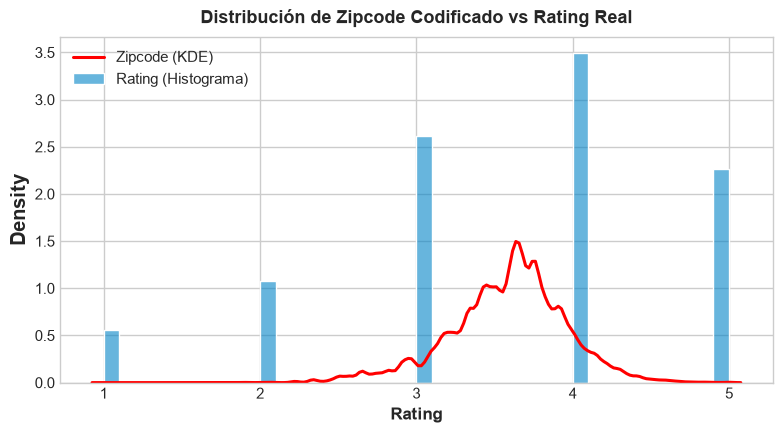

In [8]:
# Comparación de distribuciones entre la variable codificada y el target
plt.figure(dpi=95, figsize=(8, 4.5))
ax = sns.histplot(y, kde=False, stat='density', binwidth=0.1, color='#0284c7', alpha=0.6)
ax = sns.kdeplot(X_train.Zipcode, color='red', linewidth=2.2, ax=ax)
ax.set_xlabel("Rating", fontsize=12, weight='bold')
ax.set_title("Distribución de Zipcode Codificado vs Rating Real", fontsize=13, weight='bold')
ax.legend(labels=['Zipcode (KDE)', 'Rating (Histograma)'], fontsize=11)
plt.tight_layout()
plt.show()


La distribución de la característica `Zipcode` codificada sigue aproximadamente la distribución de las calificaciones reales, lo que significa que los espectadores de películas difirieron lo suficiente en sus calificaciones de un código postal a otro como para que nuestro Target Encoding pudiera capturar **información predictiva sumamente útil**.

---
##### 🛠️ Práctica 2: Evaluando la Capacidad Predictiva de la Ocupación

Aplica `TargetEncoder` sobre la columna `'Occupation'` (Ocupación del usuario) utilizando la misma partición `X_encode` y `y_encode`. Añade la columna `'Occupation_encoded'` a `X_train` y muestra las 5 ocupaciones con el promedio de rating más alto.

In [ ]:
# Escribe tu código aquí

# occ_encoder = ...
# X_train['Occupation_encoded'] = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1. Instanciamos y ajustamos el codificador para Occupation
occ_encoder = TargetEncoder(categories="auto", target_type="continuous", smooth="auto", random_state=0)
occ_encode_vals = X_encode["Occupation"].values.reshape(-1, 1)
occ_encoder.fit(occ_encode_vals, y_encode.astype(np.int32))

# 2. Transformamos sobre el conjunto de entrenamiento
occ_pretrain_vals = X_pretrain["Occupation"].values.reshape(-1, 1)
X_train["Occupation_encoded"] = occ_encoder.transform(occ_pretrain_vals)

# 3. Mostramos las ocupaciones con mayor calificación promedio
X_train[['Occupation', 'Occupation_encoded']].drop_duplicates().sort_values(by='Occupation_encoded', ascending=False).head(5)
```
</details>

---


---
### Recursos Adicionales y Ecosistema de Codificadores 🌐

Para profundizar en técnicas avanzadas de codificación categórica en Python, te recomendamos explorar la librería [Category Encoders](https://contrib.scikit-learn.org/category_encoders/index.html), la cual contiene una colección integral de transformadores compatibles con Scikit-Learn que implementan:
- **CatBoost Encoder** (codificación secuencial basada en tiempo/orden para evitar fuga de información).
- **Weight of Evidence (WoE)** (estándar en modelos de scoring crediticio y riesgo financiero).
- **James-Stein Encoder** y **M-Estimate Encoder** para regularización bayesiana avanzada.
- **Leave-One-Out Encoder** (excluye la observación actual al calcular la media del grupo).

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>
